# Initial Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

plt.rcParams["font.family"] = "Times New Roman"

In [4]:
file = "Einstein_A_take_3.xlsx"
column_names = [["I_77","F_77"],["I_90","F_90"],["I_110","F_110"],["I_140","F_140"],["I_170","F_170"], ["I_200", "F_200"], ["I_250","F_250"]]

points = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100])
pm = 2

df = pd.read_excel(file)

# Model
def Amplitude_model(x,A0,T):
    omega = 2* np.pi*x
    return((A0*T)/np.sqrt(1+(omega**2)*(T**2)))

p0_Amplitude_model = [0.01, 0.003]

bounds_Amplitude_model = (
    [0, 0],  # Lower bounds
    [np.inf, np.inf]  # Upper bounds
)



def temperature_dependence(T, t0, a):
    return t0*np.exp(a*(T-298))

p0_temperature_dependence = [0.003, #roomtemp lifetime
      -1, #a
      ]

bounds_temperature_dependence = [
    [0, -np.inf], #lower
    [np.inf, 0] #upper
]

def model_uncertainty(x, pop, cov):

    A0, T = pop
    omega = 2*np.pi*x
    denom = np.sqrt(1 + (omega**2)*(T**2))

    dA0 = T / denom
    dT  = A0 / (1 + (omega**2)*(T**2))**(3/2)

    var = (
        dA0**2 * cov[0,0] +
        dT**2  * cov[1,1] +
        2*dA0*dT*cov[0,1]
    )

    return np.sqrt(var)

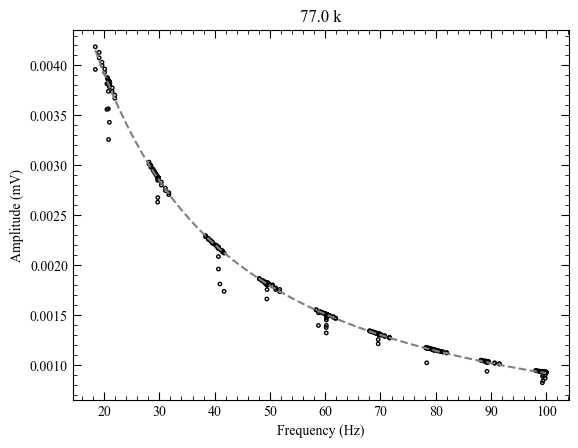

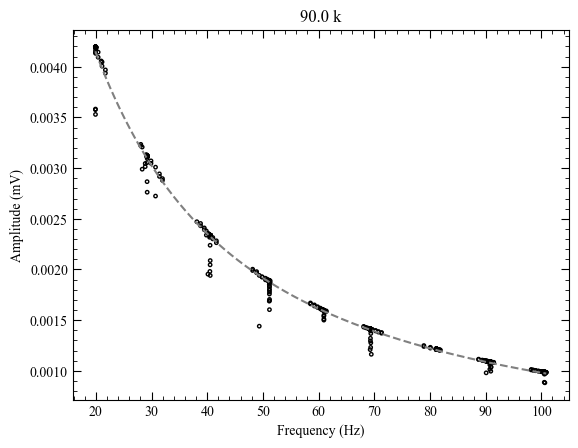

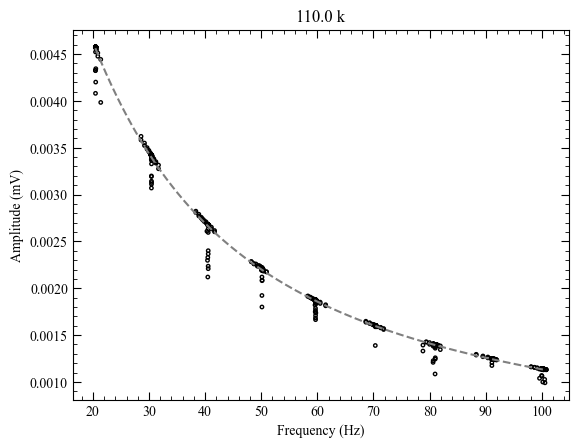

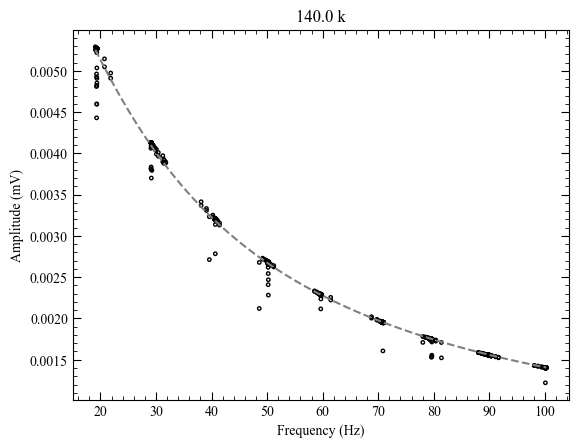

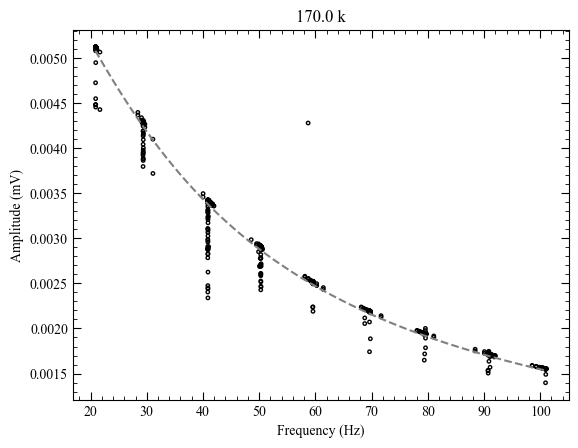

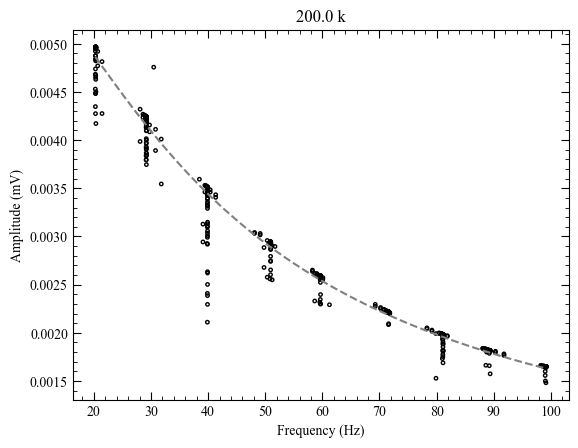

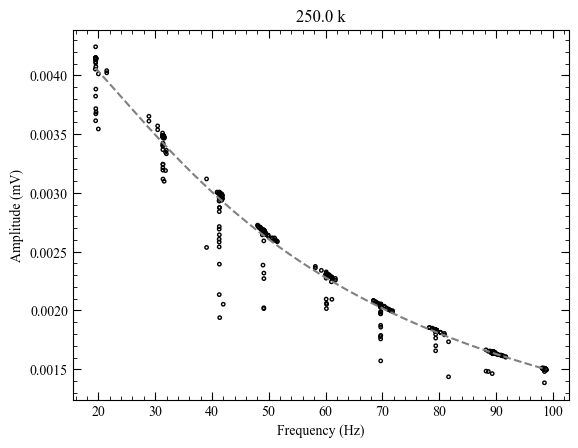

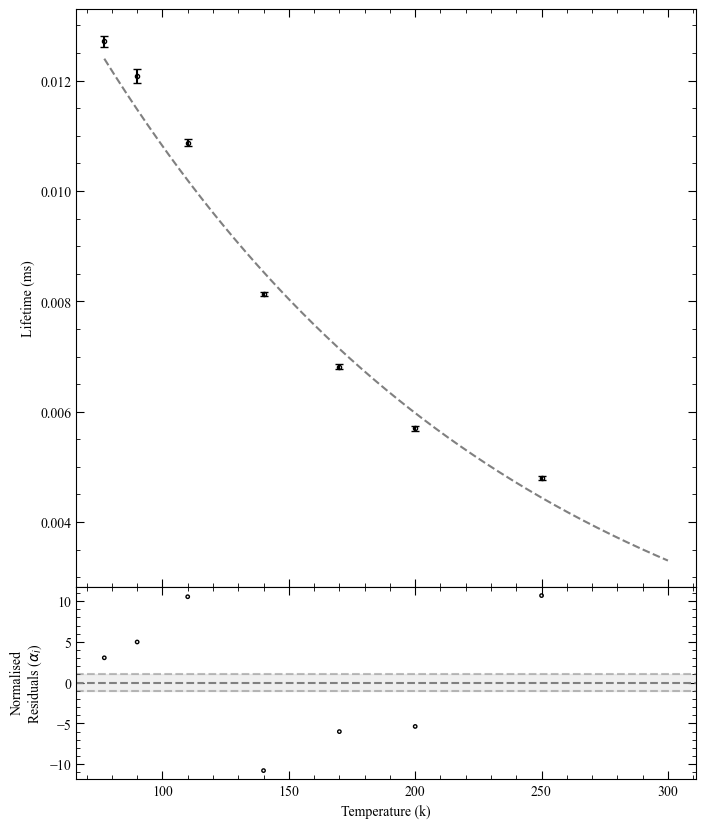

Amplitude Method lifetime: 0.00334 pm 0.00003


In [14]:
lifetimes = []
lifetime_errors = []
temperatures = []

amp_data = {}

for col in column_names:
    temp = float(col[0].split("_")[1])

    x_raw = df[col[1]]
    y_raw = df[col[0]]

    mask = np.zeros_like(x_raw, dtype = bool)

    for p in points:
        mask |= (x_raw >= p - pm) & (x_raw <= p + pm)

    x_sliced = x_raw[mask]
    y_sliced = y_raw[mask]

    pop, cov = curve_fit(Amplitude_model,
                         x_sliced,
                         y_sliced,
                         p0 = p0_Amplitude_model,
                         bounds = bounds_Amplitude_model,
                         maxfev = 10000)

    x_fit = np.linspace(x_sliced.min(), x_sliced.max(), 10000)

    plt.figure(1)
    plt.scatter(x_sliced, y_sliced,
                marker = 'o', facecolor = 'none',color = "black", s = 6)
    plt.plot(x_fit, Amplitude_model(x_fit, *pop),
             color = "grey", linestyle = "--")

    plt.minorticks_on()
    plt.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    plt.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

    plt.title(f"{temp} k")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (mV)")
    plt.show()

    temperatures.append(temp)
    lifetimes.append(pop[1])
    lifetime_errors.append(np.sqrt(np.diag(cov)[1]))

    amp_data[temp] = {
        "x": x_sliced,
        "y": y_sliced,
        "fit_params": pop
    }

temperatures = np.array(temperatures)
lifetimes = np.array(lifetimes)
lifetime_errors = np.array(lifetime_errors)

T_fit = np.linspace(temperatures.min(), 300, 100000)

p0 = [0.003, #roomtemp lifetime
      -0.01 #a
      ] #offset

p0_bounds = [
    [0, -np.inf], #lower
    [np.inf, 0] #upper
]

pop, cov = curve_fit(temperature_dependence,
                     temperatures,
                     lifetimes,
                     sigma = lifetime_errors,
                     absolute_sigma = True,
                     p0 = p0,
                     bounds = p0_bounds,
                     maxfev = 10000)

residuals = (lifetimes-temperature_dependence(temperatures, *pop))/lifetime_errors


fig = plt.figure(figsize = (8,10))

gs = fig.add_gridspec(
    2, 1,
    hspace = 0,
    height_ratios = [3,1],
)
ax_main = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex = ax_main)

###########
# main plot
###########

ax_main.set_ylabel("Lifetime (ms)")

ax_main.errorbar(temperatures, lifetimes, yerr= lifetime_errors,
            marker = 'o', markerfacecolor = 'none',color = "black", markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop),
          color = "grey", linestyle = "--")

###############
# residual plot
###############


ax_res.set_xlabel("Temperature (k)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")

ax_res.scatter(temperatures, residuals,
            marker = 'o', facecolor = 'none',color = "black", s = 6)

ax_res.axhspan(-1,1, color = "grey", alpha = 0.12)
ax_res.axhline(-1, color = "grey", linestyle = "--",alpha = 0.5)
ax_res.axhline(1, color = "grey", linestyle = "--", alpha = 0.5)
ax_res.axhline(0, color = "grey", linestyle = "--")

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

plt.show()

print(f"Amplitude Method lifetime: {pop[0]:.5f} pm {np.sqrt(np.diag(cov)[0]):.5f}")

# Report Plot

In [15]:
# prep

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

residual_band= Patch(
    facecolor="grey",
    alpha=0.12,
    label=r"$1\sigma$ Residuals"
)

red_cb = "#e41a1c"
blue_cb = "#377eb8"
purple_cb = "#984ea3"

laptop_savepath_amplitude = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\amplitude_plot.png"
pc_savepath_amplitude = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\amplitude_plot.png"

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm

cmap = LinearSegmentedColormap.from_list(
    "red_blue_gradient",
    [blue_cb,red_cb],
    N = 256
)

temps = np.array(list(amp_data.keys()))
norm = colors.Normalize(vmin=temps.min(), vmax=temps.max())

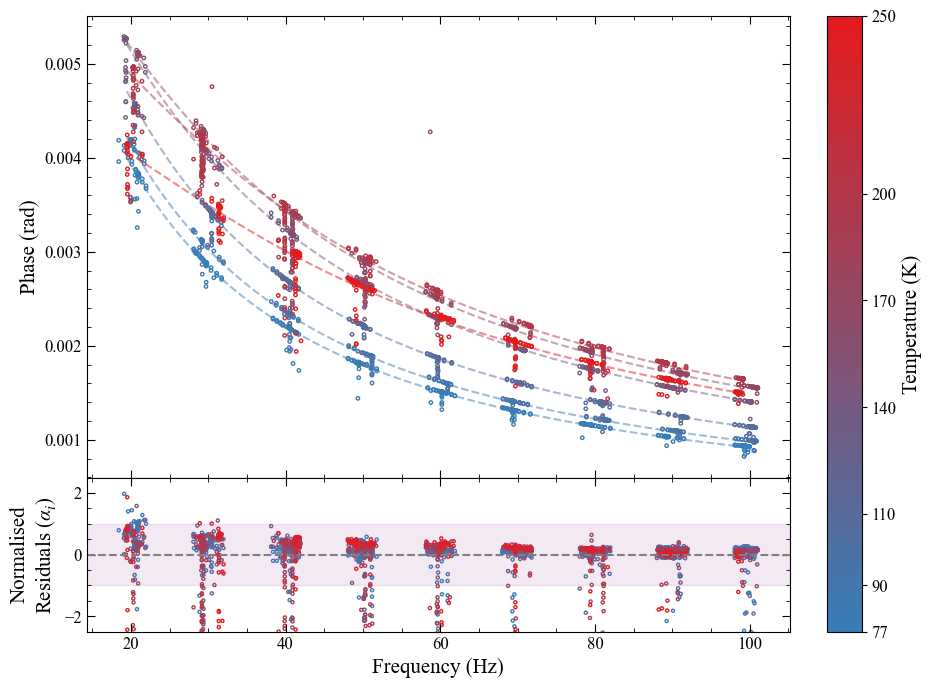

In [16]:
fig = plt.figure(figsize = (10,8))

gs = fig.add_gridspec(
    2, 2,
    hspace = 0,
    wspace = 0.1,
    height_ratios = [3,1],
    width_ratios = [20,1],
)


ax_main = fig.add_subplot(gs[0,0])
ax_res = fig.add_subplot(gs[1,0], sharex = ax_main)
ax_res.set_ylim([-2.5, 2.5])

ax_cb = fig.add_subplot(gs[:,1])

ax_main.set_ylabel("Phase (rad)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")
ax_res.set_xlabel("Frequency (Hz)")

###########
# Main Plot
###########

for (temp, data) in amp_data.items():
    pop_phase = amp_data[temp]["fit_params"]

    colour = cmap(norm(temp))

    ax_main.scatter(data["x"], data["y"],
        s=6, facecolor='none', edgecolor=colour
    )

    ax_main.plot(x_fit, Amplitude_model(x_fit, *pop_phase),
                 linestyle = "--", color = colour, alpha = 0.5)


###########
# Residuals
###########
for (temp, data) in amp_data.items():
    pop_phase = amp_data[temp]["fit_params"]
    residual = (data["y"]-Amplitude_model(data["x"], *pop_phase))
    residual /= np.std(residual)
    colour = cmap(norm(temp))
    ax_res.scatter(data["x"], residual,
                   color = colour, marker = "o", facecolor = "none", s = 5)

ax_res.axhspan(-1,1, color = purple_cb, alpha = 0.12)
ax_res.axhline(0, color = "grey", linestyle = "--")



###########
# Color Bar
###########

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cb,
    orientation="vertical"
)

cbar.set_label("Temperature (K)")
cbar.set_ticks(sorted(amp_data.keys()))



#########
# Styling
#########

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True, bottom=True, left = True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True, bottom=True, left = True)

plt.savefig(pc_savepath_amplitude,
            dpi = 150,
            bbox_inches = 'tight')
plt.show()